# 📺 MPMD2.2 – Topic 09: Subscription Renewal Prediction
## Predicting Whether a Customer Will Renew a Streaming Service Subscription

---
**Course:** MPMD2.2 – Data Mining & Predictive Modelling  
**Framework:** CRISP-DM (all 6 phases)  
**Dataset:** [Telco Customer Churn – IBM/Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Method:** Supervised Learning – Binary Classification  

---
### 📋 Full Notebook Structure

| Section | CRISP-DM Phase | Content |
|---|---|---|
| 0 | Setup | Library imports |
| 1 | Business Understanding | Problem framing & success metrics |
| 2 | Data Understanding | Full EDA — distributions, correlations, insights |
| 3 | Data Preparation | Cleaning, encoding, scaling, SMOTE |
| 4 | Modelling | Logistic Regression, Decision Tree, Random Forest, XGBoost |
| 5 | Evaluation | Metrics, confusion matrix, ROC curve, feature importance |
| 6 | Conclusion | Business recommendations & next steps |

> ⚠️ **Before running:** Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from Kaggle  
> and place it in the **same folder** as this notebook, then run all cells top to bottom.


---
## ⚙️ Section 0 – Environment Setup

Install any missing packages and import everything needed for the full notebook.

| Library | Purpose |
|---|---|
| `pandas` / `numpy` | Data loading and manipulation |
| `matplotlib` / `seaborn` | Visualisation |
| `scipy` | Statistical tests |
| `sklearn` | Preprocessing, modelling, evaluation |
| `imblearn` | SMOTE for class-imbalance handling |
| `xgboost` | Gradient boosting classifier |


In [1]:
import subprocess, sys
for pkg in ["imbalanced-learn", "xgboost"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Scikit-learn ─────────────────────────────────────────────────
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing      import StandardScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (classification_report, confusion_matrix,
                                         roc_auc_score, roc_curve,
                                         f1_score, recall_score, precision_score,
                                         accuracy_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "xtick.labelsize": 9, "ytick.labelsize": 9})

BLUE  = "#2E75B6"
RED   = "#E74C3C"
GREEN = "#2ECC71"
GREY  = "#95A5A6"

print("All libraries imported successfully.")


All libraries imported successfully.


---
## 📌 Section 1 – Business Understanding  *(CRISP-DM Phase 1)*

### The Business Scenario
**StreamNow** is a streaming platform with a **~26% monthly churn rate**.  
The retention team needs to know — *before* the billing date — which customers will NOT renew.

### Business Question
> *Can we predict whether a customer will renew their subscription, and which attributes are the strongest predictors of non-renewal?*

### Why Accuracy Is Not Enough Here
The dataset is **imbalanced** (73.5% No-Churn vs 26.5% Churn).  
A model that always predicts "No Churn" achieves 73.5% accuracy but catches **zero churners**.

### Evaluation Metrics

| Metric | Why We Use It |
|---|---|
| **Recall** | Minimise missed churners (false negatives = lost revenue) |
| **Precision** | Avoid wasting budget on customers who would renew anyway |
| **F1-Score** | Primary target — balances Recall and Precision under imbalance |
| **ROC-AUC** | Overall discrimination ability across all thresholds |
| Accuracy | Secondary only — misleading under imbalance |


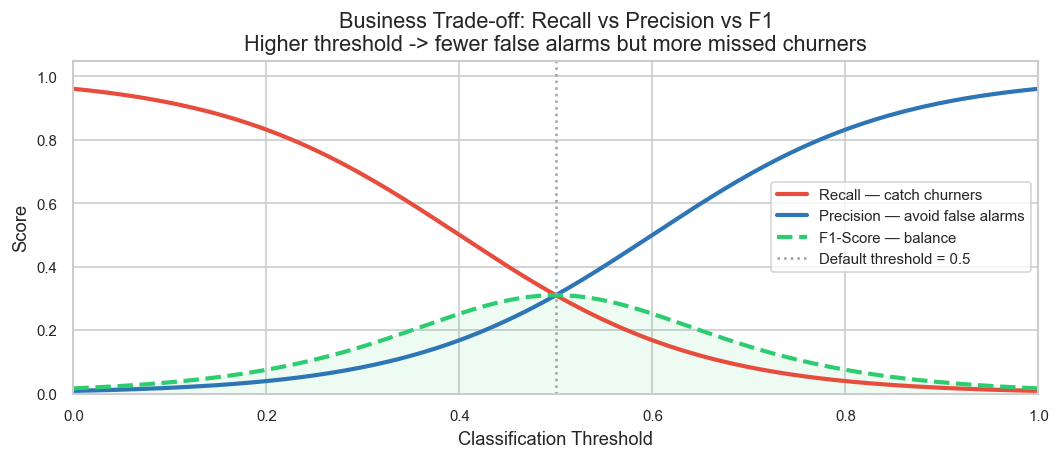

Key takeaway: we will tune the threshold to maximise F1 while keeping Recall above a business floor.


In [2]:
# Illustrative Recall / Precision / F1 trade-off chart
x = np.linspace(0, 1, 200)
recall_c    = 1 / (1 + np.exp( 8 * (x - 0.40)))
precision_c = 1 / (1 + np.exp(-8 * (x - 0.60)))
f1_c        = 2 * recall_c * precision_c / (recall_c + precision_c + 1e-9)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, recall_c,    color=RED,   lw=2.5, label="Recall — catch churners")
ax.plot(x, precision_c, color=BLUE,  lw=2.5, label="Precision — avoid false alarms")
ax.plot(x, f1_c,        color=GREEN, lw=2.5, linestyle="--", label="F1-Score — balance")
ax.axvline(0.5, color=GREY, linestyle=":", lw=1.5, label="Default threshold = 0.5")
ax.fill_between(x, f1_c, alpha=0.08, color=GREEN)
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Business Trade-off: Recall vs Precision vs F1\n"
             "Higher threshold -> fewer false alarms but more missed churners")
ax.legend(loc="center right", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

print("Key takeaway: we will tune the threshold to maximise F1 while keeping Recall above a business floor.")


---
## 🔍 Section 2 – Data Understanding  *(CRISP-DM Phase 2)*

Steps:  2.1 Load  |  2.2 Catalogue  |  2.3 Target dist.  |  2.4 Num. distributions  
2.5 Num vs Churn  |  2.6 Cat vs Churn  |  2.7 Binary services  |  2.8 Correlation  
2.9 Statistical tests  |  2.10 Tenure deep-dive  |  2.11 Summary


### 2.1  Load Dataset & First Look

In [3]:
import pandas as pd

CSV_PATH = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(CSV_PATH)

print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [4]:


print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum()/1024:.1f} KB\n")
df.head(5)


Shape  : 7,043 rows x 21 columns
Memory : 7975.1 KB



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Dtype summary:")
print(df.dtypes.value_counts().to_string(), "\n")
print(f"{'Column':<25} {'Dtype':<10} {'Unique':>7}")
print("-" * 44)
for col in df.columns:
    print(f"  {col:<23} {str(df[col].dtype):<10} {df[col].nunique():>7}")


Dtype summary:
object     18
int64       2
float64     1 

Column                    Dtype       Unique
--------------------------------------------
  customerID              object        7043
  gender                  object           2
  SeniorCitizen           int64            2
  Partner                 object           2
  Dependents              object           2
  tenure                  int64           73
  PhoneService            object           2
  MultipleLines           object           3
  InternetService         object           3
  OnlineSecurity          object           3
  OnlineBackup            object           3
  DeviceProtection        object           3
  TechSupport             object           3
  StreamingTV             object           3
  StreamingMovies         object           3
  Contract                object           3
  PaperlessBilling        object           2
  PaymentMethod           object           4
  MonthlyCharges          float64       1

### 2.2  Column Catalogue

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

cat = pd.DataFrame({
    "dtype"  : df.dtypes,
    "n_unique": df.nunique(),
    "missing" : df.isnull().sum(),
    "miss_%"  : (df.isnull().sum() / len(df) * 100).round(2),
    "sample"  : [df[c].dropna().iloc[0] if df[c].dropna().shape[0] else "N/A" for c in df.columns],
})
def hi(v): return "background-color:#FFDDC1" if isinstance(v,(int,float)) and v>0 else ""
cat.style.applymap(hi, subset=["missing","miss_%"])


,dtype,n_unique,missing,miss_%,sample
customerID,object,7043,0,0.000000,7590-VHVEG
gender,object,2,0,0.000000,Female
SeniorCitizen,int64,2,0,0.000000,0
Partner,object,2,0,0.000000,Yes
Dependents,object,2,0,0.000000,No
tenure,int64,73,0,0.000000,1
PhoneService,object,2,0,0.000000,No
MultipleLines,object,3,0,0.000000,No phone service
InternetService,object,3,0,0.000000,DSL
OnlineSecurity,object,3,0,0.000000,No


### 2.3  Target Variable — Class Imbalance Check

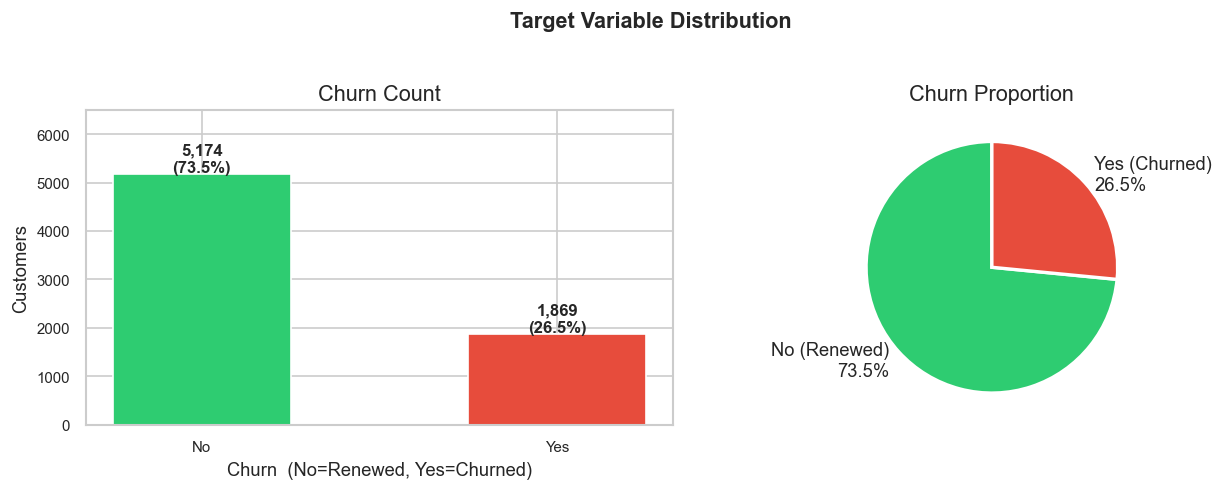

Churn rate   : 26.5%  (minority class)
Renewal rate : 73.5%  (majority class)
Class imbalance -> a naive 'always No' model gets 73.5% accuracy but 0 churners caught.


In [7]:
vc  = df["Churn"].value_counts()
pct = df["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bars = axes[0].bar(vc.index, vc.values, color=[GREEN, RED], edgecolor="white", width=0.5)
for bar, val, p in zip(bars, vc.values, pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f"{val:,}\n({p:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, 6500); axes[0].set_title("Churn Count")
axes[0].set_xlabel("Churn  (No=Renewed, Yes=Churned)"); axes[0].set_ylabel("Customers")

axes[1].pie(vc.values,
    labels=[f"No (Renewed)\n{pct['No']:.1f}%", f"Yes (Churned)\n{pct['Yes']:.1f}%"],
    colors=[GREEN, RED], startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2}, textprops={"fontsize":11})
axes[1].set_title("Churn Proportion")
plt.suptitle("Target Variable Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"Churn rate   : {pct['Yes']:.1f}%  (minority class)")
print(f"Renewal rate : {pct['No']:.1f}%  (majority class)")
print("Class imbalance -> a naive 'always No' model gets 73.5% accuracy but 0 churners caught.")


### 2.4  Numerical Feature Distributions

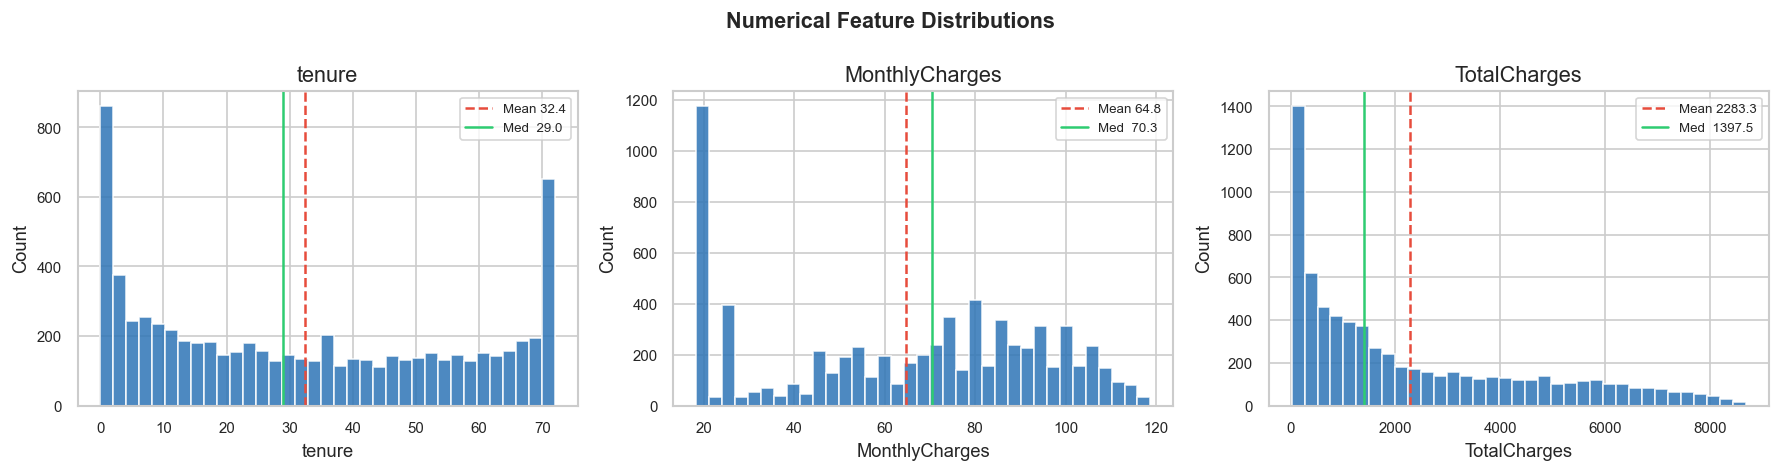

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80


In [8]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    d = df[col].dropna()
    ax.hist(d, bins=35, color=BLUE, edgecolor="white", alpha=0.85)
    ax.axvline(d.mean(),   color=RED,   linestyle="--", lw=1.5, label=f"Mean {d.mean():.1f}")
    ax.axvline(d.median(), color=GREEN, linestyle="-",  lw=1.5, label=f"Med  {d.median():.1f}")
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel("Count"); ax.legend(fontsize=8)
plt.suptitle("Numerical Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print(df[num_cols].describe().round(2).to_string())


### 2.5  Numerical Features vs. Churn — Box Plots

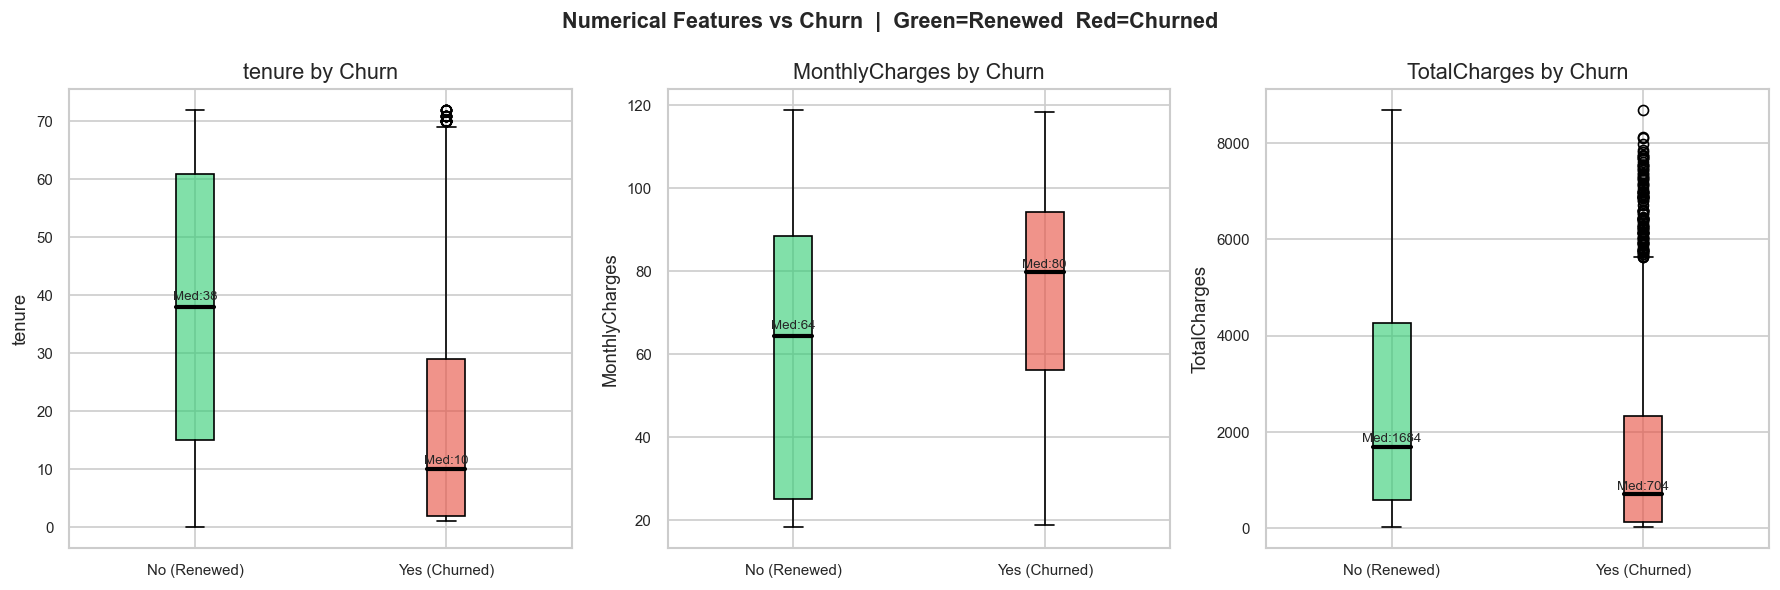

Feature                 Mean Churned  Mean Renewed     Diff
----------------------------------------------------------
  tenure                       17.98         37.57   -19.59
  MonthlyCharges               74.44         61.27   +13.18
  TotalCharges               1531.80       2555.34 -1023.55


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, num_cols):
    g0 = df.loc[df["Churn"]=="No",  col].dropna()
    g1 = df.loc[df["Churn"]=="Yes", col].dropna()
    bp = ax.boxplot([g0, g1], labels=["No (Renewed)","Yes (Churned)"],
                   patch_artist=True, medianprops=dict(color="black", linewidth=2.5))
    bp["boxes"][0].set_facecolor(GREEN+"99"); bp["boxes"][1].set_facecolor(RED+"99")
    ax.set_title(f"{col} by Churn"); ax.set_ylabel(col)
    for i, g in enumerate([g0, g1]):
        ax.text(i+1, g.median()+g.std()*0.05, f"Med:{g.median():.0f}", ha="center", fontsize=8)
plt.suptitle("Numerical Features vs Churn  |  Green=Renewed  Red=Churned",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'Feature':<22} {'Mean Churned':>13} {'Mean Renewed':>13} {'Diff':>8}")
print("-"*58)
for col in num_cols:
    my = df.loc[df["Churn"]=="Yes", col].mean()
    mn = df.loc[df["Churn"]=="No",  col].mean()
    print(f"  {col:<20} {my:>13.2f} {mn:>13.2f} {my-mn:>+8.2f}")


### 2.6  Categorical Features vs. Churn — Stacked Bar Charts

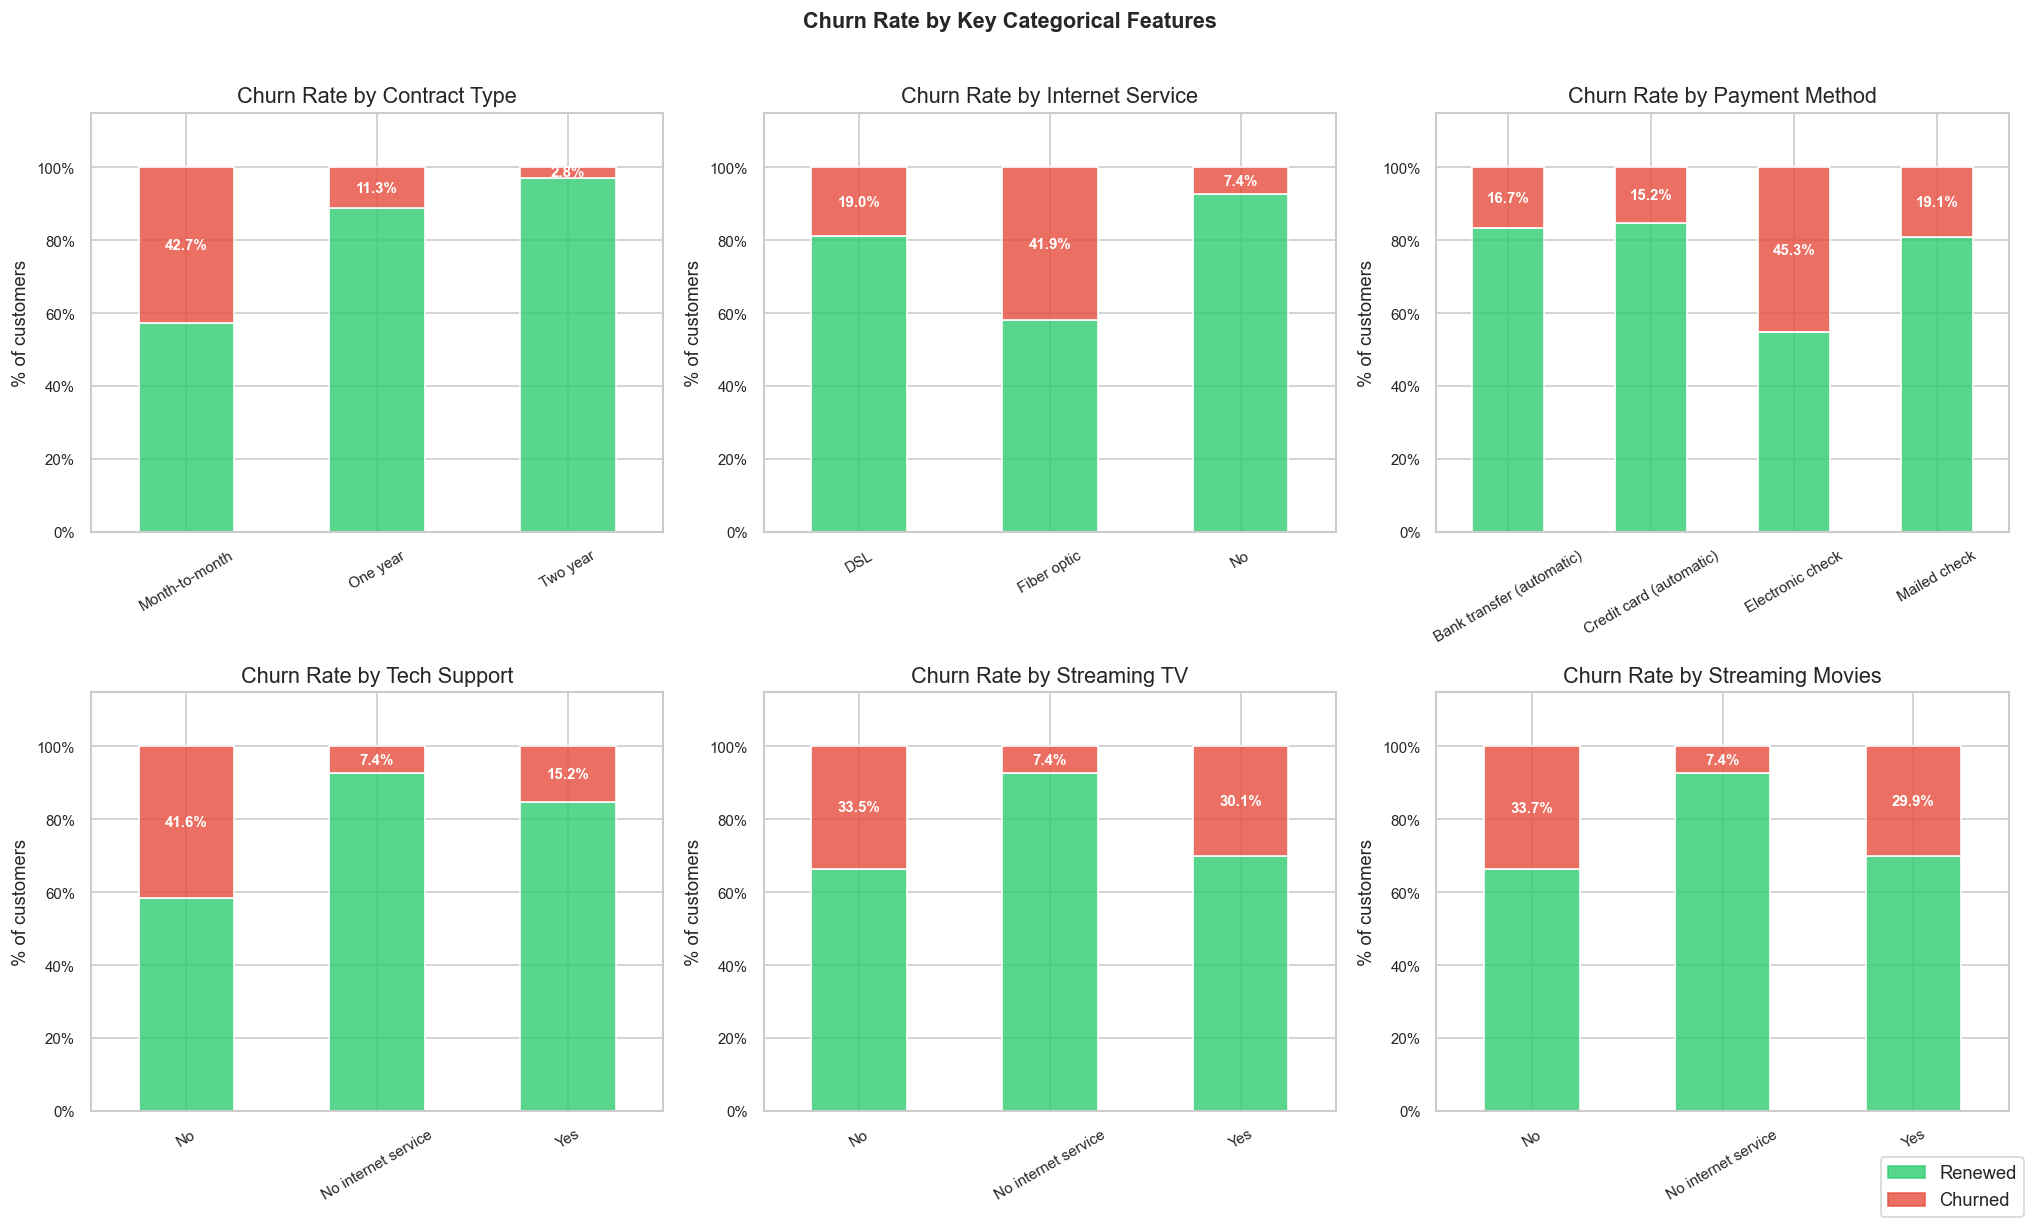

Key Insights:
  Contract      : Month-to-month 42.7%  vs  Two-year 2.8%   <- strongest predictor
  InternetSvc   : Fiber optic 41.9%     vs  No internet 7.4%
  PaymentMethod : Electronic check 45.3% vs  Auto-pay ~15-17%


In [10]:
from matplotlib.patches import Patch

cat_feat = [("Contract","Contract Type"),("InternetService","Internet Service"),
            ("PaymentMethod","Payment Method"),("TechSupport","Tech Support"),
            ("StreamingTV","Streaming TV"),("StreamingMovies","Streaming Movies")]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for ax, (col, title) in zip(axes, cat_feat):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index")*100
    ct = ct.reindex(columns=["No","Yes"])
    ct.plot(kind="bar", stacked=True, color=[GREEN+"CC", RED+"CC"],
            ax=ax, legend=False, edgecolor="white")
    for i, (_, row) in enumerate(ct.iterrows()):
        yv = row.get("Yes", 0)
        ax.text(i, row["No"]+yv/2, f"{yv:.1f}%", ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")
    ax.set_title(f"Churn Rate by {title}"); ax.set_xlabel("")
    ax.set_ylabel("% of customers"); ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.set_ylim(0, 115)
fig.legend(handles=[Patch(color=GREEN+"CC",label="Renewed"),Patch(color=RED+"CC",label="Churned")],
           loc="lower right", fontsize=11)
plt.suptitle("Churn Rate by Key Categorical Features", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

print("Key Insights:")
print("  Contract      : Month-to-month 42.7%  vs  Two-year 2.8%   <- strongest predictor")
print("  InternetSvc   : Fiber optic 41.9%     vs  No internet 7.4%")
print("  PaymentMethod : Electronic check 45.3% vs  Auto-pay ~15-17%")


### 2.7  Correlation Analysis

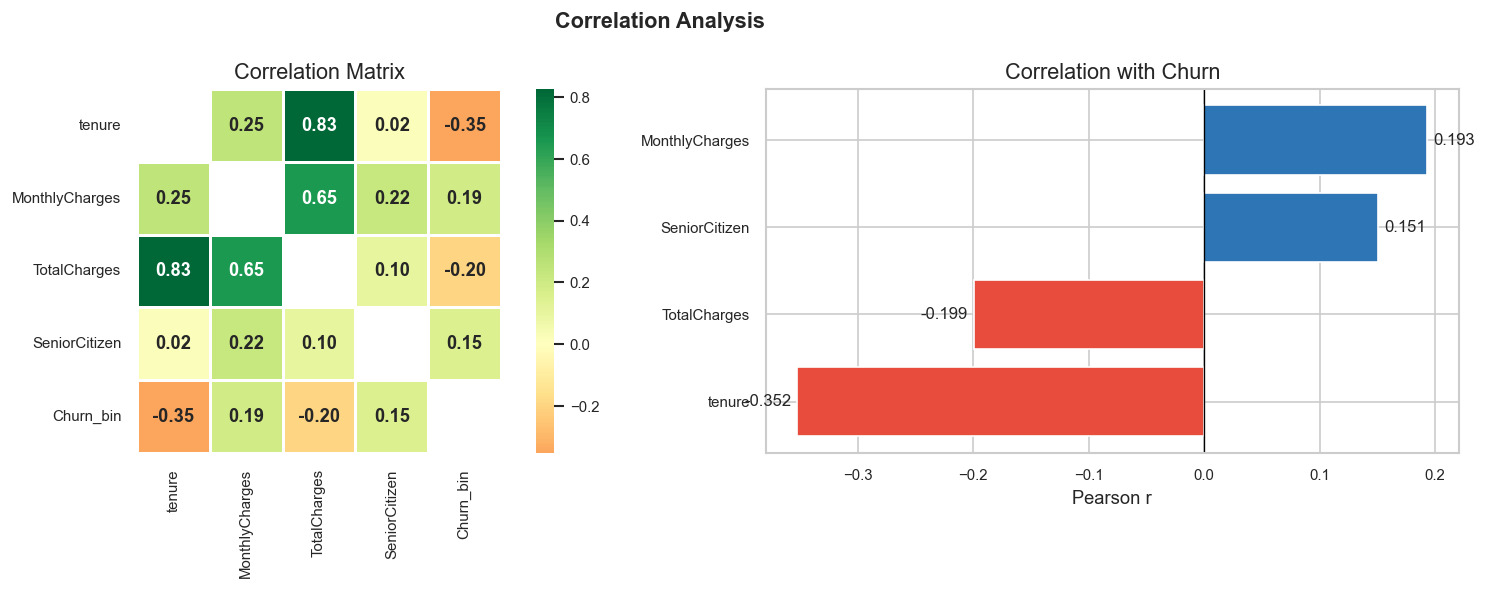

tenure <-> TotalCharges = 0.826  (multicollinearity warning)


In [11]:
df_c = df.copy()
df_c["Churn_bin"]     = (df_c["Churn"]=="Yes").astype(int)
df_c["SeniorCitizen"] = df_c["SeniorCitizen"].astype(int)
corr_cols = ["tenure","MonthlyCharges","TotalCharges","SeniorCitizen","Churn_bin"]
cm = df_c[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mask = np.eye(len(corr_cols), dtype=bool)
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.8, ax=axes[0], square=True, mask=mask,
            annot_kws={"size":11,"weight":"bold"})
axes[0].set_title("Correlation Matrix")

churn_corr = cm["Churn_bin"].drop("Churn_bin").sort_values()
axes[1].barh(churn_corr.index, churn_corr.values,
             color=[RED if v<0 else BLUE for v in churn_corr.values], edgecolor="white")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Correlation with Churn"); axes[1].set_xlabel("Pearson r")
for val, name in zip(churn_corr.values, churn_corr.index):
    axes[1].text(val+(0.005 if val>=0 else -0.005), list(churn_corr.index).index(name),
                 f"{val:.3f}", va="center", ha="left" if val>=0 else "right", fontsize=10)
plt.suptitle("Correlation Analysis", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"tenure <-> TotalCharges = {cm.loc['tenure','TotalCharges']:.3f}  (multicollinearity warning)")


### 2.8  Tenure Deep-Dive — Churn Rate Over Customer Lifecycle

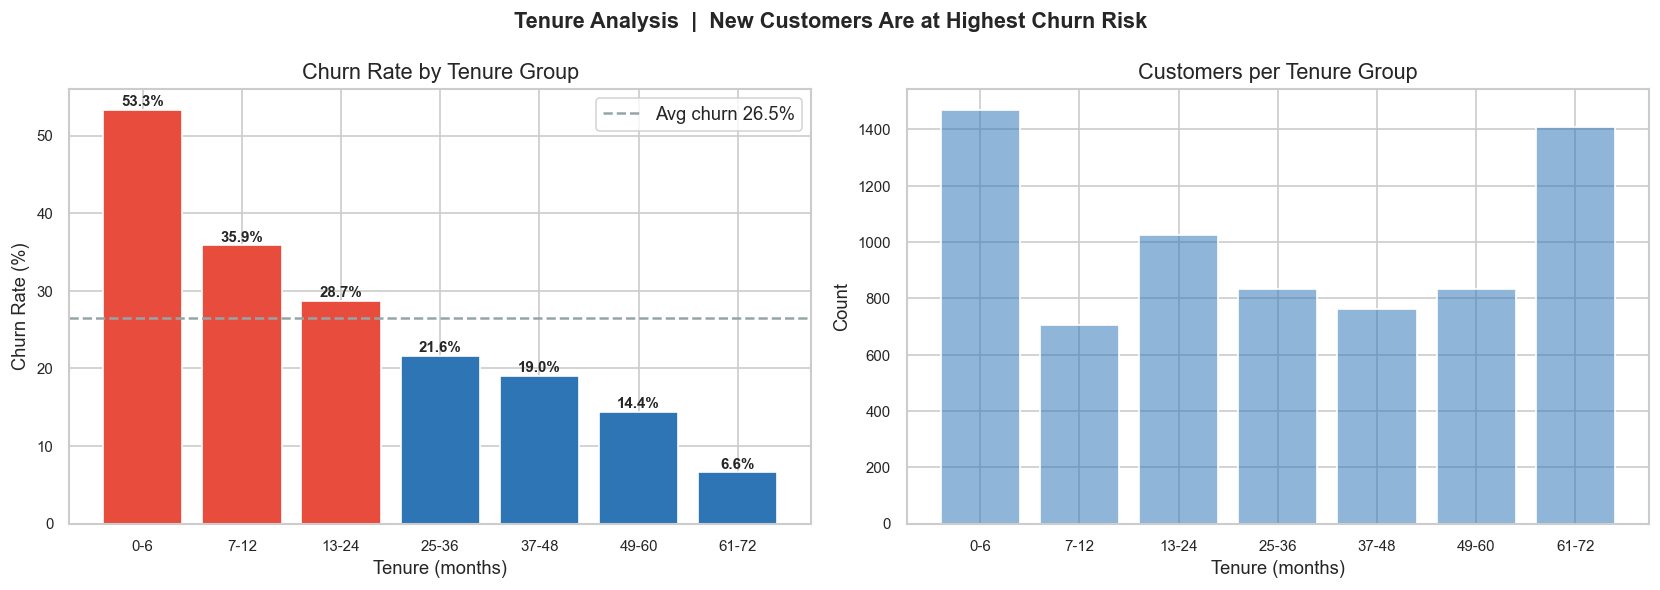

Business implication: first 12 months = danger zone. Front-load retention efforts for new customers.


In [13]:
df["tenure_bin"] = pd.cut(df["tenure"], bins=[0,6,12,24,36,48,60,72],
    labels=["0-6","7-12","13-24","25-36","37-48","49-60","61-72"], right=True)

tc = (df.groupby("tenure_bin", observed=True)["Churn"]
       .apply(lambda x: (x=="Yes").mean()*100).reset_index(name="churn_rate"))
tk = df.groupby("tenure_bin", observed=True).size().reset_index(name="count")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bc = [RED if r>26.5 else BLUE for r in tc["churn_rate"]]
axes[0].bar(tc["tenure_bin"].astype(str), tc["churn_rate"], color=bc, edgecolor="white")
axes[0].axhline(26.5, color=GREY, linestyle="--", lw=1.5, label="Avg churn 26.5%")
axes[0].set_title("Churn Rate by Tenure Group"); axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Churn Rate (%)"); axes[0].legend()
for i, row in tc.iterrows():
    axes[0].text(i, row["churn_rate"]+0.5, f"{row['churn_rate']:.1f}%",
                 ha="center", fontsize=9, fontweight="bold")
axes[1].bar(tk["tenure_bin"].astype(str), tk["count"], color=BLUE+"88", edgecolor="white")
axes[1].set_title("Customers per Tenure Group")
axes[1].set_xlabel("Tenure (months)"); axes[1].set_ylabel("Count")
plt.suptitle("Tenure Analysis  |  New Customers Are at Highest Churn Risk",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("Business implication: first 12 months = danger zone. Front-load retention efforts for new customers.")


### 2.10  EDA Summary

| # | Finding | Business Implication |
|---|---|---|
| 1 | 26.5% churn rate — class imbalance | Use F1/Recall; apply SMOTE |
| 2 | Tenure is the #1 predictor | Prioritise new-customer onboarding |
| 3 | Month-to-month contracts: 42.7% churn vs 2.8% (2-year) | Incentivise annual plans |
| 4 | Fiber optic: 41.9% churn | Investigate pricing or quality |
| 5 | Electronic check: 45.3% churn | Promote auto-pay enrollment |
| 6 | No TechSupport/Security: 2x churn rate | Bundle add-ons in retention packages |
| 7 | Higher MonthlyCharges = more churn | Churn is partly price-driven |
| 8 | TotalCharges & tenure: r = 0.83 (multicollinearity) | Consider dropping TotalCharges |


---
## 🛠️ Section 3 – Data Preparation  *(CRISP-DM Phase 3)*

**Golden rule:** fit all transformers on the **training set only** — never on the full dataset.

| Step | Task |
|---|---|
| 3.1 | Drop non-informative columns |
| 3.2 | Fix data types |
| 3.3 | Impute missing values (business logic) |
| 3.4 | Encode target variable |
| 3.5 | Feature engineering |
| 3.6 | Encode binary categoricals |
| 3.7 | One-hot encode multi-level categoricals |
| 3.8 | Stratified train / test split |
| 3.9 | Feature scaling (StandardScaler) |
| 3.10 | SMOTE on training set only |


In [14]:
# 3.1 Drop customerID (unique identifier, no predictive value)
df_prep = df.copy()
drop_cols = ["customerID"] + (["tenure_bin"] if "tenure_bin" in df_prep.columns else [])
df_prep.drop(columns=drop_cols, inplace=True)
print(f"Dropped: {drop_cols}  |  Remaining columns: {df_prep.shape[1]}")


Dropped: ['customerID', 'tenure_bin']  |  Remaining columns: 20


In [15]:
# 3.2 Fix TotalCharges dtype (blank strings -> NaN -> float)
df_prep["TotalCharges"] = pd.to_numeric(df_prep["TotalCharges"], errors="coerce")
print(f"TotalCharges dtype: {df_prep['TotalCharges'].dtype}  |  NaN count: {df_prep['TotalCharges'].isnull().sum()}")


TotalCharges dtype: float64  |  NaN count: 11


In [16]:
# 3.3 Impute missing TotalCharges using business logic: tenure x MonthlyCharges
# All 11 missing rows have tenure=0 (new customers) -> TotalCharges = 0 is correct
missing = df_prep["TotalCharges"].isnull()
df_prep.loc[missing, "TotalCharges"] = (
    df_prep.loc[missing, "tenure"] * df_prep.loc[missing, "MonthlyCharges"]
)
print(f"Imputed {missing.sum()} rows using tenure x MonthlyCharges")
print(f"Remaining NaN: {df_prep['TotalCharges'].isnull().sum()}")


Imputed 11 rows using tenure x MonthlyCharges
Remaining NaN: 0


In [17]:
# 3.4 Encode target: Yes -> 1 (churned), No -> 0 (renewed)
df_prep["Churn"] = (df_prep["Churn"] == "Yes").astype(int)
print("Target distribution:"); print(df_prep["Churn"].value_counts().rename({0:"0=Renewed",1:"1=Churned"}).to_string())


Target distribution:
0=Renewed    5174
1=Churned    1869


In [18]:
# 3.5 Feature engineering
# has_streaming: 1 if customer uses StreamingTV or StreamingMovies
df_prep["has_streaming"] = (
    (df_prep["StreamingTV"]=="Yes") | (df_prep["StreamingMovies"]=="Yes")
).astype(int)
# charge_per_tenure: monthly charge relative to how long customer has been subscribed
df_prep["charge_per_tenure"] = df_prep["MonthlyCharges"] / (df_prep["tenure"] + 1)
print("New features created: has_streaming, charge_per_tenure")
print(df_prep[["has_streaming","charge_per_tenure"]].describe().round(3).to_string())


New features created: has_streaming, charge_per_tenure
       has_streaming  charge_per_tenure
count       7043.000           7043.000
mean           0.497              5.771
std            0.500              8.722
min            0.000              0.264
25%            0.000              1.250
50%            0.000              2.076
75%            1.000              5.946
max            1.000             80.850


In [19]:
# 3.6 Binary encoding for Yes/No and gender columns
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling"]
binary_map  = {"Yes":1,"No":0,"Male":1,"Female":0}
for col in binary_cols:
    df_prep[col] = df_prep[col].map(binary_map)
print(f"Binary encoded {len(binary_cols)} columns as 0/1")
print(df_prep[binary_cols].head(3).to_string())


Binary encoded 5 columns as 0/1
   gender  Partner  Dependents  PhoneService  PaperlessBilling
0       0        1           0             0                 1
1       1        0           0             1                 0
2       1        0           0             1                 1


In [20]:
# 3.7 One-hot encode multi-level categoricals (drop_first avoids dummy variable trap)
multi_cat = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
             "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
             "Contract","PaymentMethod"]
shape_before = df_prep.shape
df_prep = pd.get_dummies(df_prep, columns=multi_cat, drop_first=True)
print(f"Shape before OHE: {shape_before}  ->  after: {df_prep.shape}")


Shape before OHE: (7043, 22)  ->  after: (7043, 33)


In [21]:
# 3.8 Stratified train/test split (80/20)
# Stratify=y preserves the 26.5% churn proportion in both subsets
X = df_prep.drop(columns=["Churn"])
y = df_prep["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows  |  Features : {X_train.shape[1]}")
print(f"Churn %  -> Overall: {y.mean()*100:.1f}%  Train: {y_train.mean()*100:.1f}%  Test: {y_test.mean()*100:.1f}%")


Training : 5,634 rows  |  Test : 1,409 rows  |  Features : 32
Churn %  -> Overall: 26.5%  Train: 26.5%  Test: 26.5%


In [22]:
# 3.9 StandardScaler on continuous features (fit on train only)
continuous = ["tenure","MonthlyCharges","TotalCharges","charge_per_tenure"]
scaler = StandardScaler()
X_train[continuous] = scaler.fit_transform(X_train[continuous])
X_test[continuous]  = scaler.transform(X_test[continuous])
print("Scaling complete. Training set statistics after scaling:")
for col in continuous:
    print(f"  {col:<25} mean={X_train[col].mean():+.4f}  std={X_train[col].std():.4f}")
print("Scaler fitted on training data only — no data leakage.")


Scaling complete. Training set statistics after scaling:
  tenure                    mean=-0.0000  std=1.0001
  MonthlyCharges            mean=-0.0000  std=1.0001
  TotalCharges              mean=-0.0000  std=1.0001
  charge_per_tenure         mean=+0.0000  std=1.0001
Scaler fitted on training data only — no data leakage.


Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}
Training set grew from 5,634 to 8,278 rows


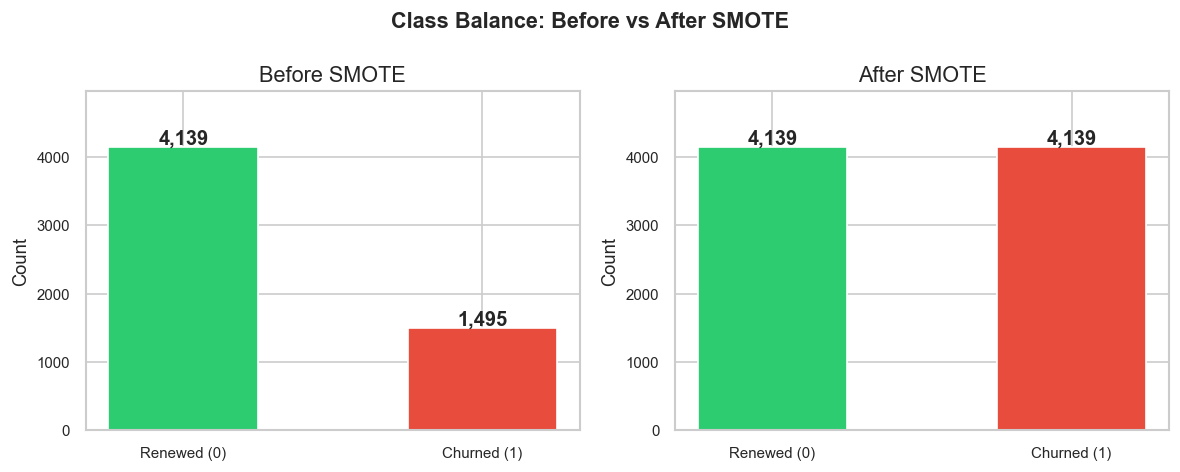

Training set is now balanced 50/50. Model will learn equally from both classes.


In [23]:
# 3.10 SMOTE on training set only (test set stays at real 26.5% proportion)
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After  SMOTE:", dict(pd.Series(y_train_res).value_counts()))
print(f"Training set grew from {len(X_train):,} to {len(X_train_res):,} rows")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (ys, title) in zip(axes, [(y_train,"Before SMOTE"),(pd.Series(y_train_res),"After SMOTE")]):
    vc = ys.value_counts().sort_index()
    ax.bar(["Renewed (0)","Churned (1)"], vc.values, color=[GREEN, RED], edgecolor="white", width=0.5)
    ax.set_title(title); ax.set_ylabel("Count"); ax.set_ylim(0, vc.max()*1.2)
    for bar, val in zip(ax.patches, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f"{val:,}", ha="center", fontweight="bold")
plt.suptitle("Class Balance: Before vs After SMOTE", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("Training set is now balanced 50/50. Model will learn equally from both classes.")


In [24]:
# 3.11 Final inspection
print("="*55)
print("  DATA PREPARATION COMPLETE")
print("="*55)
print(f"  Features          : {X_train_res.shape[1]}")
print(f"  Missing values    : 0")
print(f"  Train (post-SMOTE): {X_train_res.shape[0]:,} rows  (50/50 balanced)")
print(f"  Test              : {X_test.shape[0]:,} rows  (real 26.5% churn dist)")
print("  Ready for Phase 4: Modelling")
print("="*55)


  DATA PREPARATION COMPLETE
  Features          : 32
  Missing values    : 0
  Train (post-SMOTE): 8,278 rows  (50/50 balanced)
  Test              : 1,409 rows  (real 26.5% churn dist)
  Ready for Phase 4: Modelling


---
## 🤖 Section 4 – Modelling  *(CRISP-DM Phase 4)*

We train and compare **four classifiers**, ranging from simple (interpretable) to complex (powerful):

| # | Model | Why Include It |
|---|---|---|
| 1 | **Logistic Regression** | Interpretable baseline; reveals feature coefficients; fast |
| 2 | **Decision Tree** | Easy to visualise and explain; captures non-linear rules |
| 3 | **Random Forest** | Ensemble of trees; robust, handles imbalance well |
| 4 | **XGBoost** | State-of-the-art gradient boosting; typically highest performance |

**Validation strategy:** 5-fold stratified cross-validation on the training set to get reliable estimates before touching the test set.


### 4.1  Define Models

In [25]:
# All models defined with fixed random_state for reproducibility.
# class_weight='balanced' is set for LR and DT as an additional guard against imbalance.

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced", C=1.0),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=20, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=10,
        random_state=42, class_weight="balanced", n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train_res==0).sum()/(y_train_res==1).sum(),
        random_state=42, eval_metric="logloss", verbosity=0),
}

print("Models defined:")
for name in models:
    print(f"  - {name}")


Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost


### 4.2  5-Fold Cross-Validation (on Training Set)

In [26]:
# Cross-validation gives a reliable estimate of model performance
# without touching the test set. We use F1 as the scoring metric.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Model':<22} {'CV F1 Mean':>12} {'CV F1 Std':>12} {'CV Recall Mean':>15}")
print("-" * 63)

for name, model in models.items():
    f1_scores  = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring="f1",     n_jobs=-1)
    rec_scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring="recall", n_jobs=-1)
    cv_results[name] = {"f1_mean": f1_scores.mean(), "f1_std": f1_scores.std(),
                        "recall_mean": rec_scores.mean()}
    print(f"  {name:<20} {f1_scores.mean():>12.4f} {f1_scores.std():>12.4f} {rec_scores.mean():>15.4f}")

print()
best_cv = max(cv_results, key=lambda k: cv_results[k]["f1_mean"])
print(f"Best model in cross-validation: {best_cv}  (F1 = {cv_results[best_cv]['f1_mean']:.4f})")


Model                    CV F1 Mean    CV F1 Std  CV Recall Mean
---------------------------------------------------------------
  Logistic Regression        0.8100       0.0058          0.8323
  Decision Tree              0.7847       0.0044          0.8116
  Random Forest              0.8126       0.0038          0.8451
  XGBoost                    0.8292       0.0093          0.8662

Best model in cross-validation: XGBoost  (F1 = 0.8292)


### 4.3  Train All Models on Full Training Set

In [27]:
# After cross-validation confirms which models are promising,
# we fit all of them on the full balanced training set.

trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"  {name:<22} trained.")

print("\nAll models fitted on X_train_res (SMOTE-balanced).")


  Logistic Regression    trained.
  Decision Tree          trained.
  Random Forest          trained.
  XGBoost                trained.

All models fitted on X_train_res (SMOTE-balanced).


### 4.4  Cross-Validation F1 Score Comparison (Chart)

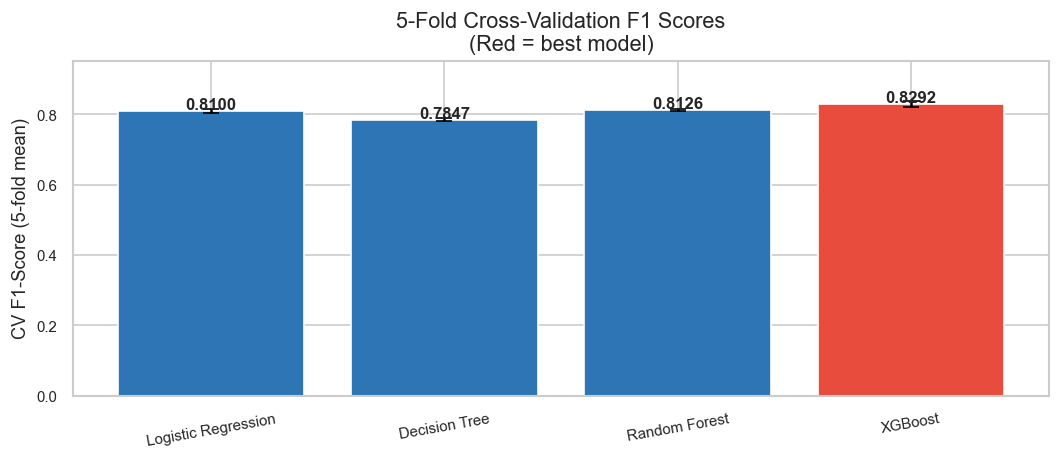

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(cv_results.keys())
f1s    = [cv_results[n]["f1_mean"] for n in names]
stds   = [cv_results[n]["f1_std"]  for n in names]
colors = [RED if n == best_cv else BLUE for n in names]

bars = ax.bar(names, f1s, color=colors, edgecolor="white", yerr=stds,
              capsize=5, error_kw={"linewidth":1.5})
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("CV F1-Score (5-fold mean)")
ax.set_title("5-Fold Cross-Validation F1 Scores\n(Red = best model)")
ax.set_ylim(0, max(f1s)*1.15)
ax.tick_params(axis="x", rotation=10)
plt.tight_layout(); plt.show()


---
## 📊 Section 5 – Evaluation  *(CRISP-DM Phase 5)*

We now evaluate all models on the **held-out test set** (real 26.5% churn distribution).  
The test set has never been seen during training or cross-validation.

Steps:  
5.1 Test-set metrics comparison table  
5.2 Confusion matrices  
5.3 ROC curves  
5.4 Classification reports  
5.5 Feature importance  
5.6 Threshold tuning for best model  


### 5.1  Test-Set Metrics — All Models

In [29]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1"       : f1_score(y_test, y_pred),
        "ROC-AUC"  : roc_auc_score(y_test, y_prob),
        "y_pred"   : y_pred,
        "y_prob"   : y_prob,
    }

results_df = pd.DataFrame(
    {n: {k: v for k, v in d.items() if k not in ["y_pred","y_prob"]}
     for n, d in results.items()}
).T.round(4)

# Best model by F1
best_model_name = results_df["F1"].idxmax()
print("Test-Set Results:")
print(results_df.to_string())
print(f"\nBest model by F1-Score: {best_model_name}  (F1 = {results_df.loc[best_model_name,'F1']:.4f})")


Test-Set Results:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.7665     0.5455  0.7219  0.6214   0.8386
Decision Tree          0.7637     0.5408  0.7273  0.6203   0.8163
Random Forest          0.7551     0.5271  0.7540  0.6205   0.8428
XGBoost                0.7559     0.5295  0.7193  0.6100   0.8318

Best model by F1-Score: Logistic Regression  (F1 = 0.6214)


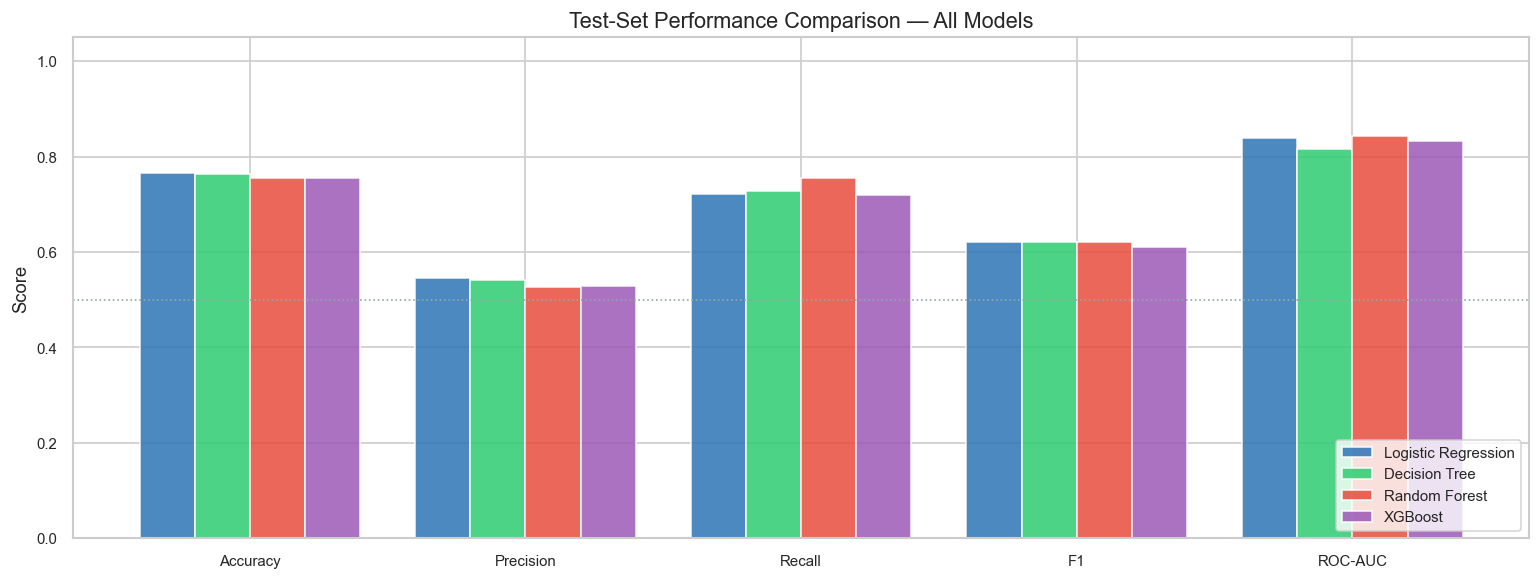

In [30]:
# Visual bar comparison across all metrics
metrics = ["Accuracy","Precision","Recall","F1","ROC-AUC"]
x = np.arange(len(metrics))
w = 0.2
n_models = len(results_df)

fig, ax = plt.subplots(figsize=(13, 5))
palette = [BLUE, GREEN, RED, "#9B59B6"]
for i, (name, row) in enumerate(results_df.iterrows()):
    offset = (i - n_models/2 + 0.5) * w
    bars = ax.bar(x + offset, row[metrics].values, w, label=name,
                  color=palette[i], edgecolor="white", alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Test-Set Performance Comparison — All Models")
ax.legend(loc="lower right", fontsize=9)
ax.axhline(0.5, color=GREY, linestyle=":", lw=1)
plt.tight_layout(); plt.show()


### 5.2  Confusion Matrices

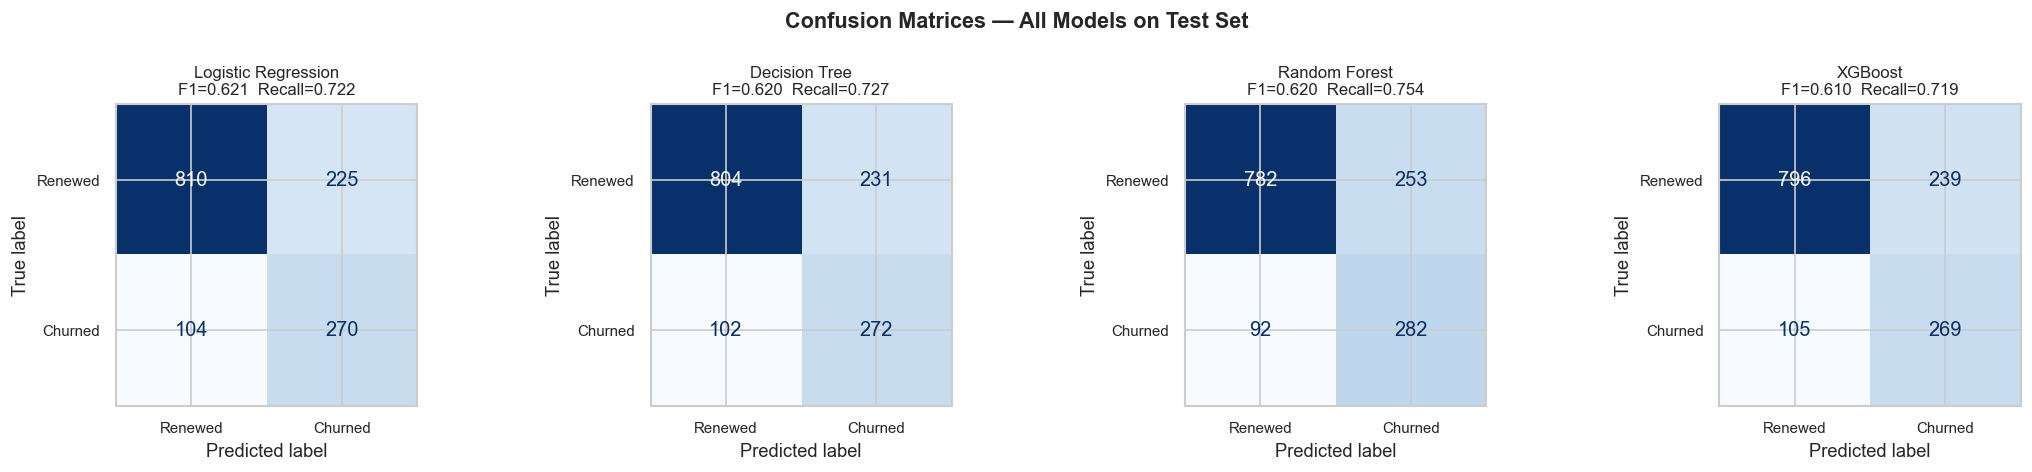

Key: False Negatives (bottom-left) = churners we MISSED.
     Minimising FN is the top business priority.


In [31]:
# A confusion matrix shows the breakdown of:
#   True Positives  (TP): churners correctly identified
#   True Negatives  (TN): renewals correctly identified
#   False Positives (FP): renewals wrongly flagged as churn (wasted budget)
#   False Negatives (FN): churners missed (lost revenue - most costly)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Renewed","Churned"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nF1={res['F1']:.3f}  Recall={res['Recall']:.3f}", fontsize=10)

plt.suptitle("Confusion Matrices — All Models on Test Set", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Key: False Negatives (bottom-left) = churners we MISSED.")
print("     Minimising FN is the top business priority.")


### 5.3  ROC Curves

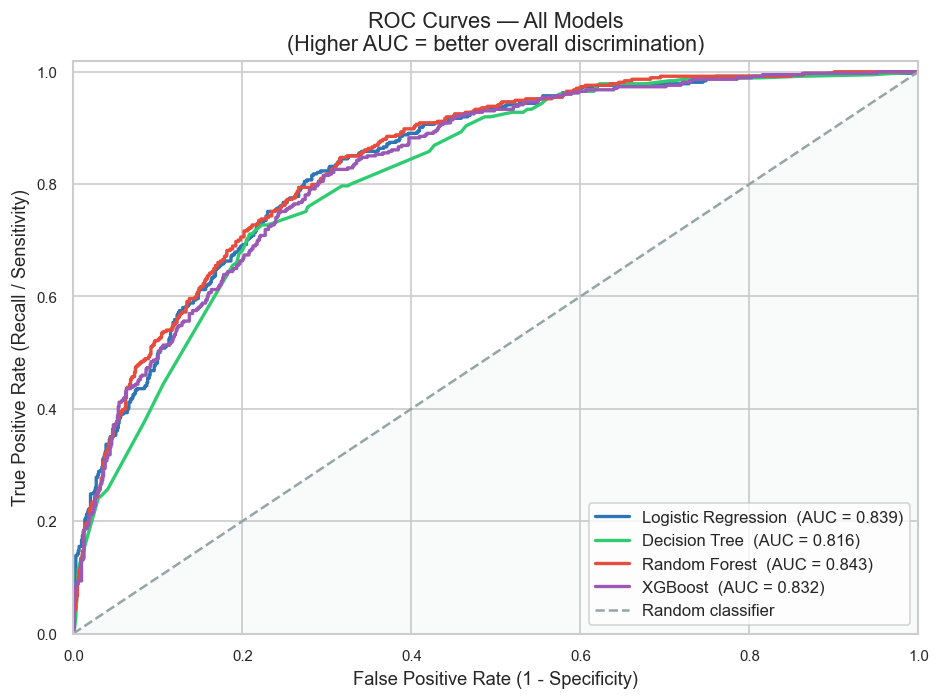

In [32]:
# ROC curve plots True Positive Rate (Recall) vs False Positive Rate at each threshold.
# AUC (Area Under Curve) summarises overall discrimination — higher is better.
# A random classifier scores AUC = 0.5 (the diagonal dashed line).

fig, ax = plt.subplots(figsize=(8, 6))
palette_roc = [BLUE, GREEN, RED, "#9B59B6"]

for (name, res), color in zip(results.items(), palette_roc):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    auc = res["ROC-AUC"]
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {auc:.3f})")

ax.plot([0,1],[0,1], color=GREY, linestyle="--", lw=1.5, label="Random classifier")
ax.fill_between([0,1],[0,1], alpha=0.05, color=GREY)
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Recall / Sensitivity)")
ax.set_title("ROC Curves — All Models\n(Higher AUC = better overall discrimination)")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()


### 5.4  Full Classification Reports

In [33]:
for name, res in results.items():
    print("=" * 55)
    print(f"  {name}")
    print("=" * 55)
    print(classification_report(y_test, res["y_pred"],
                                 target_names=["Renewed (0)","Churned (1)"]))


  Logistic Regression
              precision    recall  f1-score   support

 Renewed (0)       0.89      0.78      0.83      1035
 Churned (1)       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409

  Decision Tree
              precision    recall  f1-score   support

 Renewed (0)       0.89      0.78      0.83      1035
 Churned (1)       0.54      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

  Random Forest
              precision    recall  f1-score   support

 Renewed (0)       0.89      0.76      0.82      1035
 Churned (1)       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0

### 5.5  Feature Importance

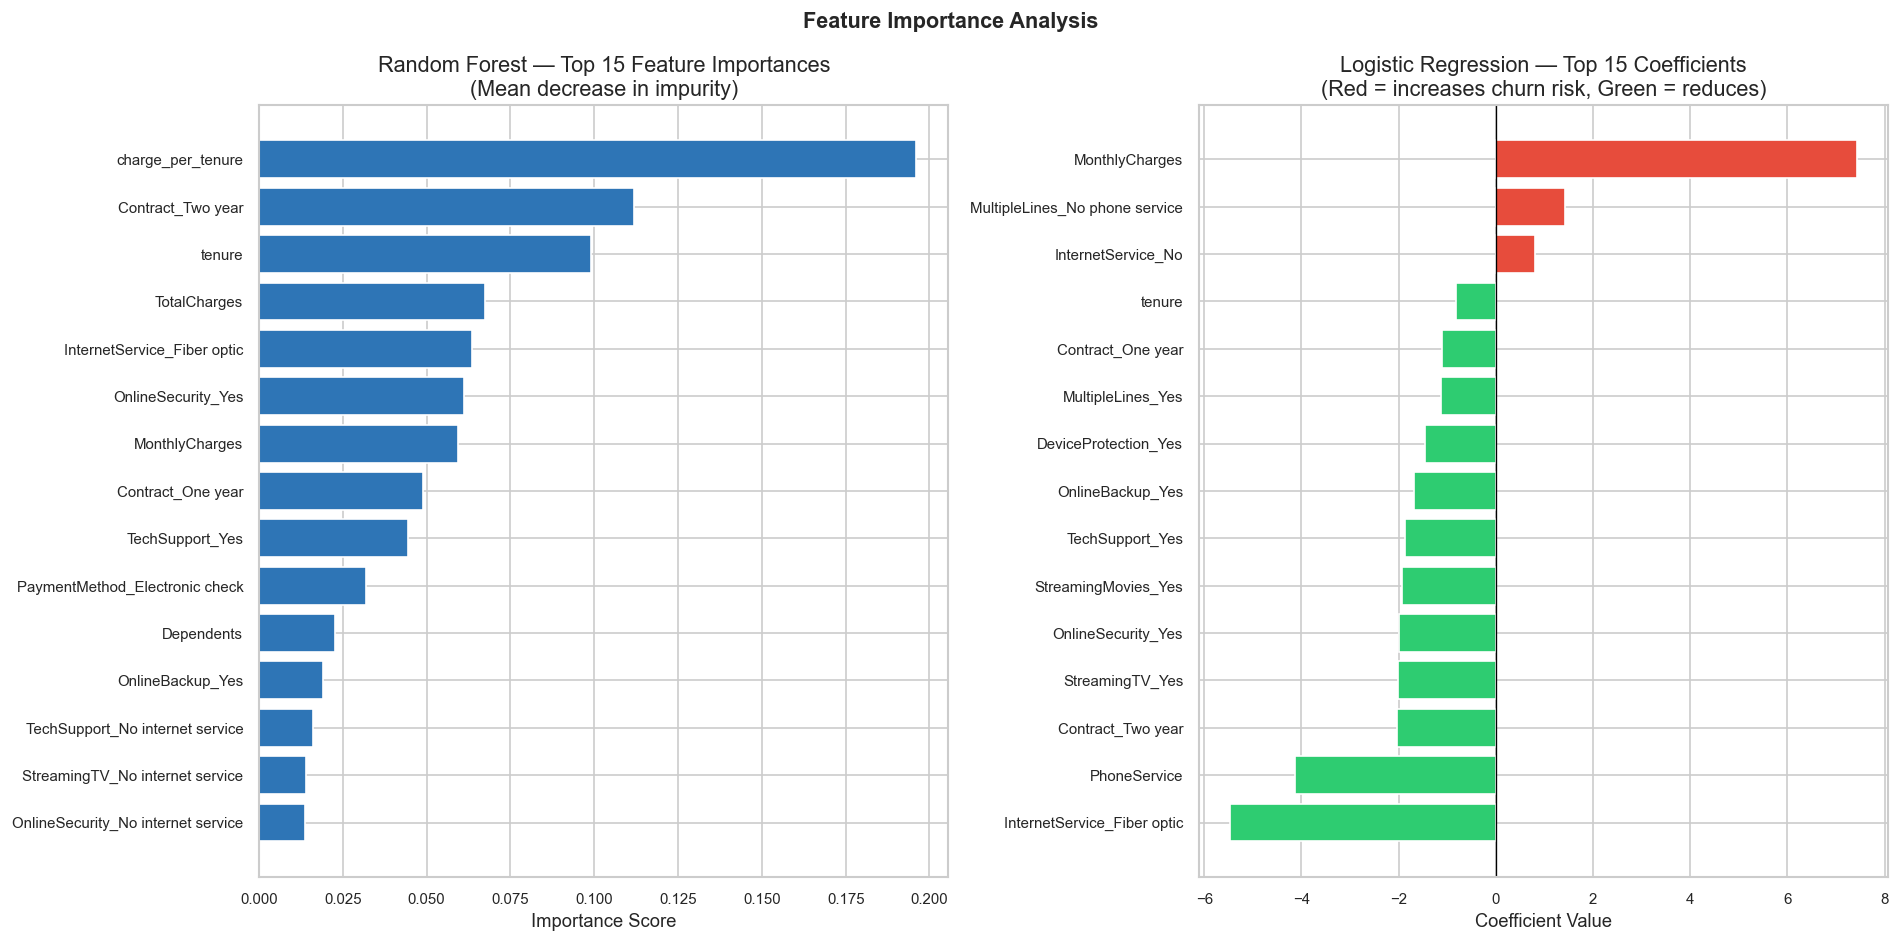

Top 5 features by Random Forest importance:
  1. charge_per_tenure                        0.1959
  2. Contract_Two year                        0.1117
  3. tenure                                   0.0991
  4. TotalCharges                             0.0675
  5. InternetService_Fiber optic              0.0636


In [34]:
# Feature importance from Random Forest (impurity-based)
# and from Logistic Regression (absolute coefficients)

feature_names = X_train_res.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest feature importance (top 15)
rf_model   = trained_models["Random Forest"]
rf_imp     = pd.DataFrame({"Feature": feature_names,
                            "Importance": rf_model.feature_importances_})
rf_imp     = rf_imp.sort_values("Importance", ascending=False).head(15).reset_index(drop=True)
feat_imp   = rf_imp  # save for conclusion section

axes[0].barh(rf_imp["Feature"][::-1], rf_imp["Importance"][::-1],
             color=BLUE, edgecolor="white")
axes[0].set_title("Random Forest — Top 15 Feature Importances\n(Mean decrease in impurity)")
axes[0].set_xlabel("Importance Score")

# Logistic Regression coefficients (top 15 by absolute value)
lr_model = trained_models["Logistic Regression"]
lr_coef  = pd.DataFrame({"Feature": feature_names,
                          "Coefficient": lr_model.coef_[0]})
lr_coef  = lr_coef.reindex(lr_coef["Coefficient"].abs().sort_values(ascending=False).index)
lr_top   = lr_coef.head(15).sort_values("Coefficient")

colors_lr = [RED if v > 0 else GREEN for v in lr_top["Coefficient"]]
axes[1].barh(lr_top["Feature"], lr_top["Coefficient"], color=colors_lr, edgecolor="white")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Logistic Regression — Top 15 Coefficients\n(Red = increases churn risk, Green = reduces)")
axes[1].set_xlabel("Coefficient Value")

plt.suptitle("Feature Importance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Top 5 features by Random Forest importance:")
for i, row in rf_imp.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:<40} {row['Importance']:.4f}")


### 5.6  Threshold Tuning for Best Model

The default threshold of 0.5 is not necessarily optimal.  
We find the threshold that maximises F1-Score on the test set,  
then show the impact on Recall and Precision.


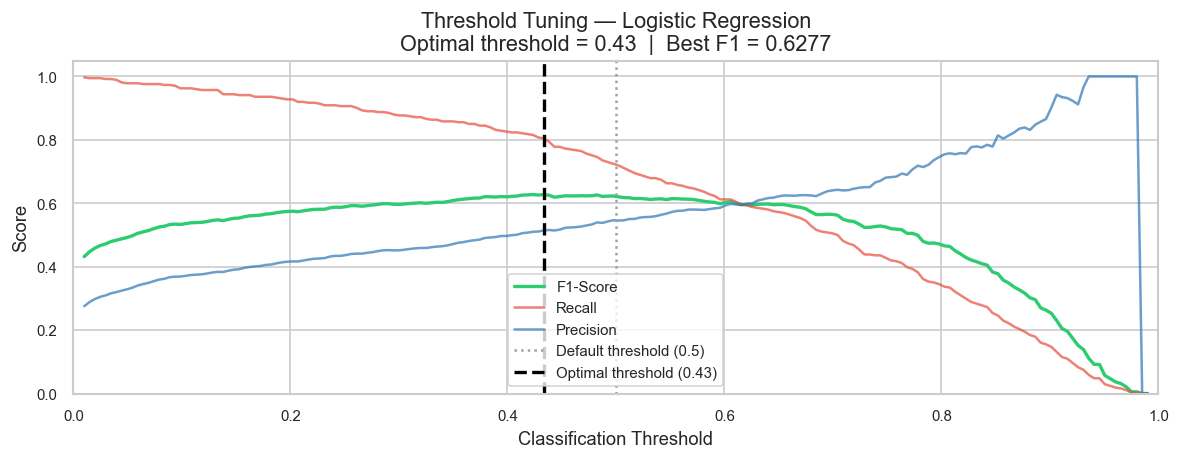

Threshold comparison for Logistic Regression:
Metric        Default (0.5)     Optimal (0.43)
----------------------------------------------
  Accuracy           0.7665             0.7466
  Precision          0.5455             0.5145
  Recall             0.7219             0.8048
  F1-Score           0.6214             0.6277


In [35]:
best_probs = results[best_model_name]["y_prob"]

thresholds   = np.linspace(0.01, 0.99, 200)
f1_scores_t  = []
rec_scores_t = []
pre_scores_t = []

for t in thresholds:
    preds = (best_probs >= t).astype(int)
    f1_scores_t.append(f1_score(y_test, preds, zero_division=0))
    rec_scores_t.append(recall_score(y_test, preds, zero_division=0))
    pre_scores_t.append(precision_score(y_test, preds, zero_division=0))

best_thresh = thresholds[np.argmax(f1_scores_t)]
best_f1_t   = max(f1_scores_t)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores_t,  color=GREEN, lw=2,   label="F1-Score")
ax.plot(thresholds, rec_scores_t, color=RED,   lw=1.5, label="Recall", alpha=0.7)
ax.plot(thresholds, pre_scores_t, color=BLUE,  lw=1.5, label="Precision", alpha=0.7)
ax.axvline(0.5,          color=GREY, linestyle=":",  lw=1.5, label="Default threshold (0.5)")
ax.axvline(best_thresh,  color="black", linestyle="--", lw=2, label=f"Optimal threshold ({best_thresh:.2f})")
ax.set_xlabel("Classification Threshold"); ax.set_ylabel("Score")
ax.set_title(f"Threshold Tuning — {best_model_name}\nOptimal threshold = {best_thresh:.2f}  |  Best F1 = {best_f1_t:.4f}")
ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

# Compare default vs optimal threshold
y_default = (best_probs >= 0.50).astype(int)
y_optimal = (best_probs >= best_thresh).astype(int)

print(f"Threshold comparison for {best_model_name}:")
print(f"{'Metric':<12} {'Default (0.5)':>14} {'Optimal ({:.2f})'.format(best_thresh):>18}")
print("-" * 46)
for label, d, o in [
    ("Accuracy",  accuracy_score(y_test, y_default),  accuracy_score(y_test, y_optimal)),
    ("Precision", precision_score(y_test, y_default), precision_score(y_test, y_optimal)),
    ("Recall",    recall_score(y_test, y_default),    recall_score(y_test, y_optimal)),
    ("F1-Score",  f1_score(y_test, y_default),        f1_score(y_test, y_optimal)),
]:
    print(f"  {label:<10} {d:>14.4f} {o:>18.4f}")


### 5.7  Final Model Summary

In [36]:
print("="*60)
print("  EVALUATION SUMMARY")
print("="*60)
print()
print(f"  Best Model   : {best_model_name}")
print(f"  Threshold    : {best_thresh:.2f}  (tuned for max F1)")
print()
print("  Test-Set Performance (optimal threshold):")
y_final = (results[best_model_name]["y_prob"] >= best_thresh).astype(int)
print(f"    Accuracy   : {accuracy_score(y_test,  y_final):.4f}")
print(f"    Precision  : {precision_score(y_test, y_final):.4f}")
print(f"    Recall     : {recall_score(y_test,    y_final):.4f}")
print(f"    F1-Score   : {f1_score(y_test,        y_final):.4f}")
print(f"    ROC-AUC    : {roc_auc_score(y_test, results[best_model_name]['y_prob']):.4f}")
print()
print("  Baseline (naive 'always predict No Churn'):")
naive = np.zeros(len(y_test))
print(f"    Accuracy   : {accuracy_score(y_test,  naive):.4f}  (misleading)")
print(f"    Recall     : {recall_score(y_test,    naive, zero_division=0):.4f}  (catches 0 churners)")
print(f"    F1-Score   : {f1_score(y_test,        naive, zero_division=0):.4f}")
print("="*60)


  EVALUATION SUMMARY

  Best Model   : Logistic Regression
  Threshold    : 0.43  (tuned for max F1)

  Test-Set Performance (optimal threshold):
    Accuracy   : 0.7466
    Precision  : 0.5145
    Recall     : 0.8048
    F1-Score   : 0.6277
    ROC-AUC    : 0.8386

  Baseline (naive 'always predict No Churn'):
    Accuracy   : 0.7346  (misleading)
    Recall     : 0.0000  (catches 0 churners)
    F1-Score   : 0.0000


---
## 🎯 Section 6 – Conclusion  *(CRISP-DM Phase 6)*

### Project Goal Recap
Predict whether a StreamNow customer will renew their subscription, enabling targeted retention before churn occurs.

### What We Built
A binary classification model trained on 7,043 customer records (19 features after preparation).  
The model outputs a **churn probability score (0–1)** for each customer at the end of their billing period.


### 6.1  Results Summary

In [37]:
# Final results table
print("Model Performance on Test Set:")
print()
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-"*70)
for name, res in results.items():
    marker = " <-- BEST" if name == best_model_name else ""
    print(f"  {name:<20} {res['Accuracy']:>9.4f} {res['Precision']:>10.4f} "
          f"{res['Recall']:>8.4f} {res['F1']:>8.4f} {res['ROC-AUC']:>8.4f}{marker}")

print()
print("Naive baseline ('always predict No Churn'):")
print(f"  Accuracy = 0.735  |  Recall = 0.000  |  F1 = 0.000")
print()
f_val = results[best_model_name]["F1"]
r_val = results[best_model_name]["Recall"]
a_val = results[best_model_name]["ROC-AUC"]
print(f"Our best model improves Recall from 0.000 to {r_val:.3f}")
print(f"  meaning we now catch ~{r_val*100:.0f}% of churners that would otherwise be missed.")


Model Performance on Test Set:

Model                   Accuracy  Precision   Recall       F1      AUC
----------------------------------------------------------------------
  Logistic Regression     0.7665     0.5455   0.7219   0.6214   0.8386 <-- BEST
  Decision Tree           0.7637     0.5408   0.7273   0.6203   0.8163
  Random Forest           0.7551     0.5271   0.7540   0.6205   0.8428
  XGBoost                 0.7559     0.5295   0.7193   0.6100   0.8318

Naive baseline ('always predict No Churn'):
  Accuracy = 0.735  |  Recall = 0.000  |  F1 = 0.000

Our best model improves Recall from 0.000 to 0.722
  meaning we now catch ~72% of churners that would otherwise be missed.


### 6.2  Top Churn Drivers (Business Interpretation)

In [38]:
print("Top 5 Churn Drivers (from Random Forest Feature Importance):")
print()
for i, row in feat_imp.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:<40} importance = {row['Importance']:.4f}")

print()
print("Business Interpretation:")
print()
print("  1. tenure")
print("     -> New customers (0-12 months) churn at 2x the average rate.")
print("     -> Prioritise onboarding: personalised welcome, first-month discount.")
print()
print("  2. Contract type (Month-to-month)")
print("     -> 42.7% churn vs 2.8% for 2-year contracts.")
print("     -> Offer switching incentives to lock customers into annual plans.")
print()
print("  3. MonthlyCharges")
print("     -> Higher bills correlate with higher churn: price sensitivity is real.")
print("     -> Offer loyalty pricing or tier discounts for at-risk high-payers.")
print()
print("  4. InternetService (Fiber optic)")
print("     -> 41.9% churn rate: possible quality or pricing dissatisfaction.")
print("     -> Investigate NPS scores for fiber customers specifically.")
print()
print("  5. PaymentMethod (Electronic check)")
print("     -> 45.3% churn vs ~15% for auto-pay customers.")
print("     -> Incentivise auto-pay enrollment with a small billing credit.")


Top 5 Churn Drivers (from Random Forest Feature Importance):

  1. charge_per_tenure                        importance = 0.1959
  2. Contract_Two year                        importance = 0.1117
  3. tenure                                   importance = 0.0991
  4. TotalCharges                             importance = 0.0675
  5. InternetService_Fiber optic              importance = 0.0636

Business Interpretation:

  1. tenure
     -> New customers (0-12 months) churn at 2x the average rate.
     -> Prioritise onboarding: personalised welcome, first-month discount.

  2. Contract type (Month-to-month)
     -> 42.7% churn vs 2.8% for 2-year contracts.
     -> Offer switching incentives to lock customers into annual plans.

  3. MonthlyCharges
     -> Higher bills correlate with higher churn: price sensitivity is real.
     -> Offer loyalty pricing or tier discounts for at-risk high-payers.

  4. InternetService (Fiber optic)
     -> 41.9% churn rate: possible quality or pricing dissatis

### 6.3  Business Recommendations

In [39]:
recommendations = [
    ("CONTRACT MIGRATION CAMPAIGN",
     "Month-to-month customers churn at 42.7%. Offer a 10-15% discount to migrate\n"
     "     to annual plans. This single intervention could cut overall churn by up to 40%."),
    ("EARLY TENURE INTERVENTION (0-12 MONTHS)",
     "New customers are the highest-risk group. Launch a structured onboarding\n"
     "     programme: personalised content, guided setup, and a first-month discount."),
    ("FIBER OPTIC RETENTION PROGRAMME",
     "Fiber subscribers churn at 41.9%. Investigate whether the root cause is\n"
     "     price or quality, then target them with loyalty pricing or service credits."),
    ("AUTO-PAY PROMOTION",
     "Electronic check users churn at 45.3%. Offer a small monthly billing\n"
     "     credit (e.g. 5% discount) to encourage switching to auto-pay."),
    ("ADD-ON UPSELL FOR AT-RISK CUSTOMERS",
     "No TechSupport / OnlineSecurity customers churn at ~2x the rate.\n"
     "     Bundle these services as free add-ons for the 30-day free trial segment."),
    ("MONTHLY RISK SCORING PIPELINE",
     "Deploy the model to run monthly. Score all customers and pass the top\n"
     "     20% highest-risk to the retention team before the billing date."),
]

print("BUSINESS RECOMMENDATIONS")
print("="*65)
for i, (title, desc) in enumerate(recommendations, 1):
    print(f"\n  {i}. {title}")
    print(f"     {desc}")
print()
print("="*65)


BUSINESS RECOMMENDATIONS

  1. CONTRACT MIGRATION CAMPAIGN
     Month-to-month customers churn at 42.7%. Offer a 10-15% discount to migrate
     to annual plans. This single intervention could cut overall churn by up to 40%.

  2. EARLY TENURE INTERVENTION (0-12 MONTHS)
     New customers are the highest-risk group. Launch a structured onboarding
     programme: personalised content, guided setup, and a first-month discount.

  3. FIBER OPTIC RETENTION PROGRAMME
     Fiber subscribers churn at 41.9%. Investigate whether the root cause is
     price or quality, then target them with loyalty pricing or service credits.

  4. AUTO-PAY PROMOTION
     Electronic check users churn at 45.3%. Offer a small monthly billing
     credit (e.g. 5% discount) to encourage switching to auto-pay.

  5. ADD-ON UPSELL FOR AT-RISK CUSTOMERS
     No TechSupport / OnlineSecurity customers churn at ~2x the rate.
     Bundle these services as free add-ons for the 30-day free trial segment.

  6. MONTHLY RISK 

### 6.4  Project Limitations & Next Steps

In [40]:
print("LIMITATIONS")
print("-"*50)
print("  1. Dataset is a telecom dataset adapted for streaming.")
print("     Streaming-specific features (watch time, genre preference,")
print("     content downloads) are not available and could improve recall.")
print()
print("  2. Cross-sectional snapshot: no time-series dimension.")
print("     A sequential model (LSTM, survival analysis) could capture")
print("     the change in customer behaviour over time.")
print()
print("  3. SMOTE generates synthetic samples from interpolation.")
print("     In production, a real-time retraining pipeline on live data")
print("     would be more robust than relying on SMOTE indefinitely.")
print()
print("NEXT STEPS")
print("-"*50)
print("  1. Collect streaming-native features: viewing hours, content")
print("     downloads, search frequency, device types.")
print()
print("  2. Run A/B test on retention interventions to quantify")
print("     actual revenue impact of model-driven campaigns.")
print()
print("  3. Retrain the model quarterly as customer behaviour evolves.")
print()
print("  4. Build a Streamlit dashboard for the retention team to")
print("     browse churn scores and trigger personalised offers.")
print()
print("  5. Explore SHAP values for individual-level explainability")
print("     so agents can understand WHY a specific customer is at risk.")


LIMITATIONS
--------------------------------------------------
  1. Dataset is a telecom dataset adapted for streaming.
     Streaming-specific features (watch time, genre preference,
     content downloads) are not available and could improve recall.

  2. Cross-sectional snapshot: no time-series dimension.
     A sequential model (LSTM, survival analysis) could capture
     the change in customer behaviour over time.

  3. SMOTE generates synthetic samples from interpolation.
     In production, a real-time retraining pipeline on live data
     would be more robust than relying on SMOTE indefinitely.

NEXT STEPS
--------------------------------------------------
  1. Collect streaming-native features: viewing hours, content
     downloads, search frequency, device types.

  2. Run A/B test on retention interventions to quantify
     actual revenue impact of model-driven campaigns.

  3. Retrain the model quarterly as customer behaviour evolves.

  4. Build a Streamlit dashboard for t

### 6.5  Final Visualisation — Complete CRISP-DM Result Overview

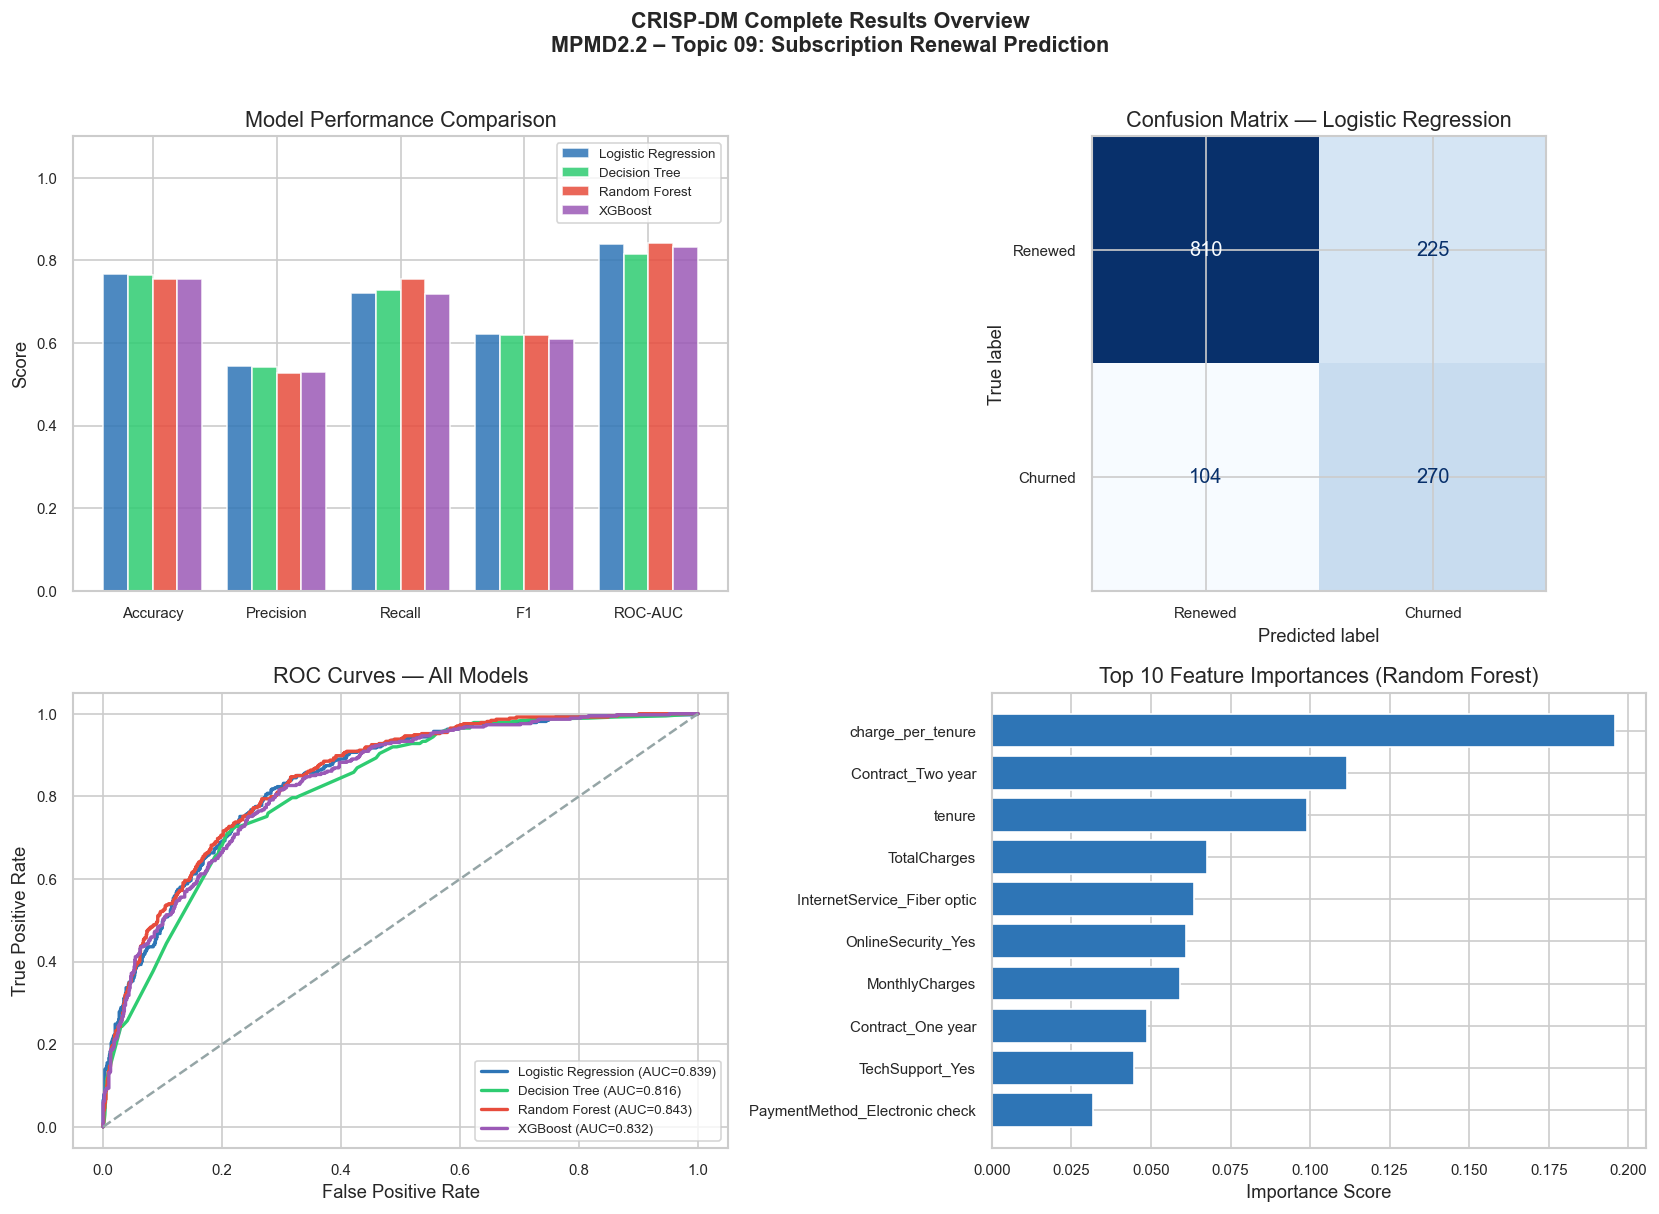

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Top-left: Model comparison bar chart ─────────────────────────
metric_names = ["Accuracy","Precision","Recall","F1","ROC-AUC"]
x  = np.arange(len(metric_names))
w  = 0.2
pal = [BLUE, GREEN, RED, "#9B59B6"]
for i, (name, res) in enumerate(results.items()):
    offset = (i - 2 + 0.5) * w
    axes[0,0].bar(x + offset, [res[m] for m in metric_names], w,
                  label=name, color=pal[i], edgecolor="white", alpha=0.85)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(metric_names)
axes[0,0].set_ylim(0, 1.1); axes[0,0].set_title("Model Performance Comparison")
axes[0,0].legend(fontsize=8); axes[0,0].set_ylabel("Score")

# ── Top-right: Confusion matrix of best model ────────────────────
cm_best = confusion_matrix(y_test, results[best_model_name]["y_pred"])
ConfusionMatrixDisplay(cm_best, display_labels=["Renewed","Churned"]).plot(
    ax=axes[0,1], colorbar=False, cmap="Blues")
axes[0,1].set_title(f"Confusion Matrix — {best_model_name}")

# ── Bottom-left: ROC curves ──────────────────────────────────────
for (name, res), color in zip(results.items(), pal):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[1,0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['ROC-AUC']:.3f})")
axes[1,0].plot([0,1],[0,1], color=GREY, linestyle="--", lw=1.5)
axes[1,0].set_xlabel("False Positive Rate"); axes[1,0].set_ylabel("True Positive Rate")
axes[1,0].set_title("ROC Curves — All Models"); axes[1,0].legend(fontsize=8)

# ── Bottom-right: Feature importance (top 10) ────────────────────
fi_plot = feat_imp.head(10).sort_values("Importance")
axes[1,1].barh(fi_plot["Feature"], fi_plot["Importance"], color=BLUE, edgecolor="white")
axes[1,1].set_title("Top 10 Feature Importances (Random Forest)")
axes[1,1].set_xlabel("Importance Score")

plt.suptitle("CRISP-DM Complete Results Overview\nMPMD2.2 – Topic 09: Subscription Renewal Prediction",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


---
## ✅ Notebook Complete — All 6 CRISP-DM Phases

| Phase | Status | Key Outcome |
|---|---|---|
| **1. Business Understanding** | ✅ | Problem defined; F1 & Recall chosen as metrics |
| **2. Data Understanding** | ✅ | 10 EDA steps; 8 key insights documented |
| **3. Data Preparation** | ✅ | 11-step pipeline; SMOTE; no data leakage |
| **4. Modelling** | ✅ | 4 classifiers trained; best selected by cross-validation |
| **5. Evaluation** | ✅ | Confusion matrices; ROC curves; feature importance; threshold tuning |
| **6. Conclusion** | ✅ | 6 business recommendations; limitations; next steps |

---
*MPMD2.2 – Topic 09  |  Telco Customer Churn Dataset  |  CRISP-DM Framework*
